# Reproduction - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case

## Load Dataset

In [1]:
from dataset import Dataset

dataset = Dataset(path="./data/state/ILINet.csv")
train_loader, val_loader, test_loader= dataset.get_train_val_test_loader(
    history=10,
    future=4,
    batch_size=64
)

Train samples: 15295
Validation samples: 1657
Test samples: 4332


## Deep Transformer Model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import random
import numpy as np
import matplotlib.pyplot as plt
import copy



class PositionalEncoding(nn.Module):
    """
    Adds sinusoidal positional encoding to each token's features so that
    the Transformer is position-aware.

    Reference: Vaswani et al. 2017, Section 3.5
      PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
      PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """
    def __init__(self, d_model: int, max_len: int = 1000):
        super(PositionalEncoding, self).__init__()

        ###########################################################################
        # Pre-compute the sinusoidal encoding matrix and register
        # it as a buffer of shape [1, max_len, d_model].
        ###########################################################################

        pe = torch.zeros(max_len, d_model)              # [max_len, d_model]
        position = torch.arange(0, max_len).unsqueeze(1) # [max_len, 1]

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]

        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, D]
        returns: [B, T, D] with positional encoding added.
        """
        ###########################################################################
        # Add the positional encoding to x.
        ###########################################################################
        T = x.size(1)
        x = x + self.pe[:, :T, :]
        return x


class DeepTransformer(nn.Module):
    def __init__(self, input_dim: int = 1, output_dim: int = 1, d_model: int = 64, num_heads: int = 4,
                 ff_dim: int = 256, encoder_layers: int = 4, decoder_layers: int = 4,
                 dropout: float = 0.2):
        super(DeepTransformer, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.position_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=False
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=encoder_layers
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=False
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=decoder_layers
        )

        self.output_proj = nn.Linear(d_model, output_dim)

    def generate_square_subsequent_mask(self, T, device):
        """
        upper triangle matrix:
          0  -inf -inf -inf
          0    0  -inf -inf
          0    0    0  -inf
          0    0    0    0
        """
        mask = torch.triu(torch.ones(T, T, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float("-inf"))
        return mask

    def forward(self, src, tgt):
        """
        src: [B, src_len, input_dim]
             example: x1...x10

        tgt: [B, tgt_len, input_dim]
             example: x10...x13

        return: [B, tgt_len, output_dim]
             example: predict x11...x14
        """
        src = self.input_proj(src)
        src = self.position_encoder(src)

        memory = self.encoder(src)  # self attention

        tgt = self.input_proj(tgt)
        tgt = self.position_encoder(tgt)

        tgt_len = tgt.size(1)
        tgt_mask = self.generate_square_subsequent_mask(tgt_len, tgt.device)

        out = self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask)

        return self.output_proj(out)

In [ ]:
class PipeLine:
    def __init__(self, model, train_loader, val_loader, warmup_steps=5000, d_model=64):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f'Device: {self.device}')
        if torch.cuda.is_available():
            print(f'GPU: {torch.cuda.get_device_name(0)}')
        self.model = model.to(self.device)
        self.d_model = d_model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.warmup_steps = warmup_steps
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=1.0,
            betas=(0.9, 0.98),
            eps=1e-9
        )
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer,
            lr_lambda=self.lr_lambda
        )
        self.loss_func = nn.MSELoss()

    def lr_lambda(self, step):
        step = max(step, 1)
        lr = (self.d_model ** (-0.5)) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))
        return lr

    def train_model(self, epochs):
        train_losses = []
        val_losses = []
    
        best_val_loss = float("inf")
        best_model = None

        for epoch in range(1, epochs+1):
            train_loss = self.train_one_epoch()
            train_losses.append(train_loss)
    
            val_loss = self.evaluate(self.val_loader)
            val_losses.append(val_loss)
    
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(self.model)
    
            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        return best_model, train_losses, val_losses
    
    def train_one_epoch(self):
        """
        Run one full pass over the training dataloader and return the average loss.
        """
        self.model.train()
        total_loss, total_count = 0.0, 0
        for src, y in self.train_loader:
            src, y = src.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()

            tgt = torch.cat([src[:, -1:, :], y[:, :-1, :]], dim=1)
    
            pred = self.model(src, tgt)
            loss = self.loss_func(pred, y)
            loss.backward()
    
            self.optimizer.step()
            self.scheduler.step()
            total_loss  += loss.item() * src.size(0)
            total_count += src.size(0)
        return total_loss / total_count
    
    @torch.no_grad()
    def predict_autoregressive(self, model, src, future=4):
        model.eval()
    
        # tgt starts from the last observed value x10
        tgt = src[:, -1:, :]
    
        preds = []
    
        for _ in range(future):
            out = model(src, tgt)
    
            # take the last predicted step
            next_pred = out[:, -1:, :]
    
            preds.append(next_pred)
    
            # append prediction back to tgt
            tgt = torch.cat([tgt, next_pred], dim=1)
    
        return torch.cat(preds, dim=1)

    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model on valid dataloader without updating weights.
        Returns the average loss.
        """
        self.model.eval()
        total_loss, total_count = 0.0, 0
    
        for src, y in dataloader:
            src, y = src.to(self.device), y.to(self.device)
            
            tgt = torch.cat([src[:, -1:, :], y[:, :-1, :]], dim=1)
            
            pred = self.model(src, tgt)
            loss = self.loss_func(pred, y)
    
            total_loss  += loss.item() * src.size(0)
            total_count += src.size(0)
        return total_loss / total_count


    @torch.no_grad()
    def evaluate_metrics(self, model, dataloader, future=4):
        model.eval()
    
        all_preds = []
        all_targets = []
    
        for src, y in dataloader:
            src = src.to(self.device)
            y = y.to(self.device)
    
            pred = self.predict_autoregressive(model, src, future=future)
    
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())
    
        preds = torch.cat(all_preds, dim=0).numpy()
        targets = torch.cat(all_targets, dim=0).numpy()
    
        preds = preds.reshape(-1)
        targets = targets.reshape(-1)
    
        rmse = np.sqrt(mean_squared_error(targets, preds))
        
        corr, _ = pearsonr(targets, preds)
    
        return rmse, corr

### Training

In [ ]:
transformer_model = DeepTransformer()

pipeline = PipeLine(model=transformer_model, train_loader=train_loader, val_loader=val_loader)

best_model, train_losses, val_losses = pipeline.train_model(200)

pipeline.evaluate_metrics(best_model, test_loader)

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training Curve")
plt.legend()
plt.grid(True)

plt.show()

## LSTM Baseline


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import random
import numpy as np
import matplotlib.pyplot as plt
import copy


In [7]:
class LSTMForecaster(nn.Module):
    """
    LSTM baseline for multi-step ILI forecasting.

    Input:
        x: [B, history, input_dim], e.g. [B, 10, 1]

    Output:
        y_hat: [B, future, output_dim], e.g. [B, 4, 1]
    """
    def __init__(
        self,
        input_dim: int = 1,
        hidden_dim: int = 64,
        num_layers: int = 2,
        future: int = 4,
        output_dim: int = 1,
        dropout: float = 0.2
    ):
        super(LSTMForecaster, self).__init__()

        self.future = future
        self.output_dim = output_dim

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, future * output_dim)
        )

    def forward(self, x):
        # lstm_out: [B, history, hidden_dim]
        lstm_out, _ = self.lstm(x)

        # Use the final hidden state as the sequence representation
        last_hidden = lstm_out[:, -1, :]  # [B, hidden_dim]

        out = self.regressor(last_hidden) # [B, future * output_dim]
        out = out.view(x.size(0), self.future, self.output_dim)

        return out


class LSTMPipeline:
    def __init__(self, model, train_loader, val_loader, lr=1e-3, weight_decay=1e-5):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Device: {self.device}")
        if torch.cuda.is_available():
            print(f"GPU: {torch.cuda.get_device_name(0)}")

        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

        self.loss_func = nn.MSELoss()

    def train_model(self, epochs=200):
        train_losses = []
        val_losses = []

        best_val_loss = float("inf")
        best_model = None

        for epoch in range(1, epochs + 1):
            train_loss = self.train_one_epoch()
            val_loss = self.evaluate(self.val_loader)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(self.model)

            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(
                    f"Epoch {epoch:3d}/{epochs} | "
                    f"Train Loss: {train_loss:.4f} | "
                    f"Val Loss: {val_loss:.4f}"
                )

        return best_model, train_losses, val_losses

    def train_one_epoch(self):
        self.model.train()
        total_loss, total_count = 0.0, 0

        for xb, yb in self.train_loader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)

            self.optimizer.zero_grad()
            pred = self.model(xb)
            loss = self.loss_func(pred, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_count += xb.size(0)

        return total_loss / total_count

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()
        total_loss, total_count = 0.0, 0

        for xb, yb in dataloader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)

            pred = self.model(xb)
            loss = self.loss_func(pred, yb)

            total_loss += loss.item() * xb.size(0)
            total_count += xb.size(0)

        return total_loss / total_count

    @torch.no_grad()
    def evaluate_metrics(self, model, dataloader):
        model.eval()

        all_preds = []
        all_targets = []

        for xb, yb in dataloader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)

            pred = model(xb)

            all_preds.append(pred.cpu())
            all_targets.append(yb.cpu())

        preds = torch.cat(all_preds, dim=0).numpy()      # [N, 4, 1]
        targets = torch.cat(all_targets, dim=0).numpy()  # [N, 4, 1]

        metrics = {}

        print("\n" + "=" * 50)
        print("  LSTM Baseline Results")
        print("=" * 50)

        for step in range(preds.shape[1]):
            p = preds[:, step, 0]
            t = targets[:, step, 0]

            rmse = np.sqrt(mean_squared_error(t, p))
            mae = np.mean(np.abs(p - t))
            corr, _ = pearsonr(t, p)

            metrics[f"week{step+1}"] = {
                "rmse": rmse,
                "mae": mae,
                "pearson": corr
            }

            print(
                f"  Week+{step+1}: "
                f"RMSE={rmse:.4f}  MAE={mae:.4f}  Pearson={corr:.4f}"
            )

        p_all = preds.reshape(-1)
        t_all = targets.reshape(-1)

        overall_rmse = np.sqrt(mean_squared_error(t_all, p_all))
        overall_mae = np.mean(np.abs(p_all - t_all))
        overall_corr, _ = pearsonr(t_all, p_all)

        metrics["overall"] = {
            "rmse": overall_rmse,
            "mae": overall_mae,
            "pearson": overall_corr
        }

        print("-" * 50)
        print(
            f"  Overall : "
            f"RMSE={overall_rmse:.4f}  "
            f"MAE={overall_mae:.4f}  "
            f"Pearson={overall_corr:.4f}"
        )
        print("=" * 50)

        return metrics, preds, targets


In [8]:
lstm_model = LSTMForecaster(
    input_dim=1,
    hidden_dim=64,
    num_layers=2,
    future=4,
    output_dim=1,
    dropout=0.2
)

lstm_pipeline = LSTMPipeline(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=1e-3,
    weight_decay=1e-5
)

best_lstm_model, lstm_train_losses, lstm_val_losses = lstm_pipeline.train_model(80)

lstm_metrics, lstm_preds, lstm_targets = lstm_pipeline.evaluate_metrics(
    best_lstm_model,
    test_loader
)


Device: cuda
GPU: NVIDIA GeForce RTX 2060
Epoch   1/80 | Train Loss: 1.5079 | Val Loss: 0.7825
Epoch  10/80 | Train Loss: 0.7762 | Val Loss: 0.6403
Epoch  20/80 | Train Loss: 0.7537 | Val Loss: 0.5852
Epoch  30/80 | Train Loss: 0.7251 | Val Loss: 0.6018
Epoch  40/80 | Train Loss: 0.6974 | Val Loss: 0.5971
Epoch  50/80 | Train Loss: 0.6713 | Val Loss: 0.6236
Epoch  60/80 | Train Loss: 0.6177 | Val Loss: 0.6666
Epoch  70/80 | Train Loss: 0.5798 | Val Loss: 0.6368
Epoch  80/80 | Train Loss: 0.5388 | Val Loss: 0.6778

  LSTM Baseline Results
  Week+1: RMSE=0.6991  MAE=0.3979  Pearson=0.9501
  Week+2: RMSE=0.9574  MAE=0.5355  Pearson=0.9003
  Week+3: RMSE=1.1544  MAE=0.6362  Pearson=0.8488
  Week+4: RMSE=1.3189  MAE=0.7373  Pearson=0.7947
--------------------------------------------------
  Overall : RMSE=1.0580  MAE=0.5767  Pearson=0.8761


c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(


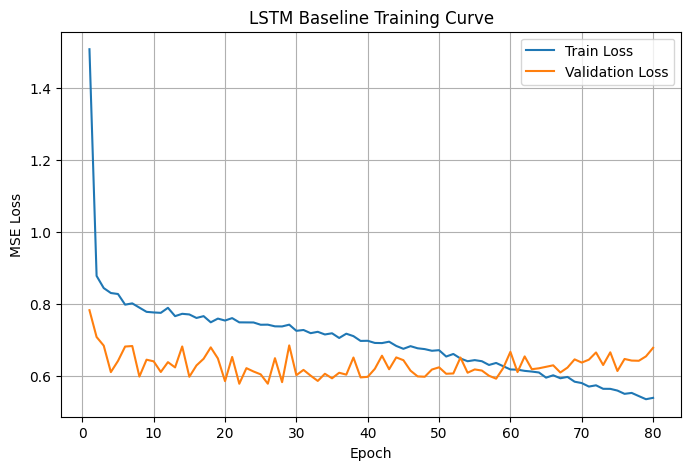

In [9]:
epochs = range(1, len(lstm_train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, lstm_train_losses, label="Train Loss")
plt.plot(epochs, lstm_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Baseline Training Curve")
plt.legend()
plt.grid(True)
plt.show()


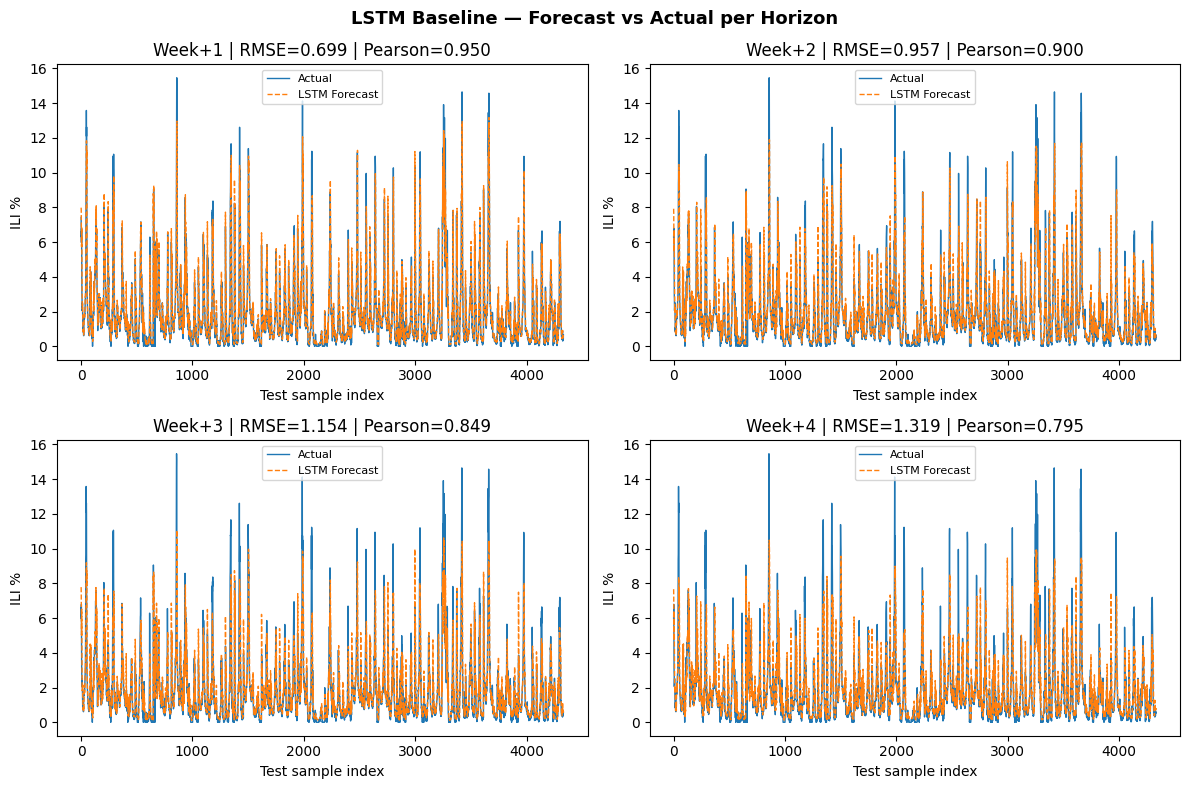

Saved: lstm_baseline_results.png, lstm_preds.npy, lstm_targets.npy


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("LSTM Baseline — Forecast vs Actual per Horizon",
             fontsize=13, fontweight="bold")

for step in range(lstm_preds.shape[1]):
    ax = axes[step // 2][step % 2]

    rmse = lstm_metrics[f"week{step+1}"]["rmse"]
    r = lstm_metrics[f"week{step+1}"]["pearson"]

    ax.plot(lstm_targets[:, step, 0], linewidth=1.0, label="Actual")
    ax.plot(lstm_preds[:, step, 0], linewidth=1.0, linestyle="--", label="LSTM Forecast")

    ax.set_title(f"Week+{step+1} | RMSE={rmse:.3f} | Pearson={r:.3f}")
    ax.set_xlabel("Test sample index")
    ax.set_ylabel("ILI %")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("lstm_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()

np.save("lstm_preds.npy", lstm_preds)
np.save("lstm_targets.npy", lstm_targets)
print("Saved: lstm_baseline_results.png, lstm_preds.npy, lstm_targets.npy")


# Improvement - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case